# Load SVM decoding results (platform paper)

Loads the aggregated `all_sess` SVM decoding outputs (deconvolved **events**) from
Farzaneh's `SVM` folder, for the three platform-paper project codes
(`VisualBehavior`, `VisualBehaviorTask1B`, `VisualBehaviorMultiscope`; excluding `4areasx2d`),
for these decoding types:

- `decode_next_image_from_omissions`
- `decode_changes_from_nochanges`
- `decode_baseline_from_nobaseline`  (candidate **events** equivalent of the old `gray_omit`)
- `gray_omit`  (**only exists as dF/F, Multiscope-only** -- no events / single-plane version)

For each (decoding type x project code) it picks the **latest** standard aggregate file
(excludes `trial_blocks/`, `matched_cells`, `sameNumNeurons`).

In [260]:
import os
import re
import glob
import numpy as np
import pandas as pd

import visual_behavior.data_access.loading as loading

## 1. Platform-paper experiments table

In [261]:
metadata_tables_dir = loading.get_metadata_tables_dir()
platform_experiments = pd.read_csv(
    os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'),
    index_col=0,
)
print(platform_experiments.shape)
platform_experiments.head()

(402, 45)


,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,
795073741,794968300,794918442,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
795953296,795742990,795625712,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181214,True,0.0,False,False,False,False,Novel 0
796308505,796251270,796236521,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181216,False,2.0,False,False,False,True,Novel 2
807752719,807356557,807208045,803517529,425493,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"['Slc17a7-IRES2-Cre', 'Camk2a-tTA']",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),M,...,lower,VISp_lower,20190111,False,-1.0,True,True,False,False,Familiar > 3
808619543,808324301,808107961,803517529,425493,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"['Slc17a7-IRES2-Cre', 'Camk2a-tTA']",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),M,...,lower,VISp_lower,20190114,True,0.0,False,False,False,False,Novel 0


## 2. Project codes

The three project codes we want come from the experiments table (we drop `4areasx2d`).

In [262]:
project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']

if 'project_code' in platform_experiments.columns:
    print(platform_experiments['project_code'].value_counts())
    exp_ids_by_project = {
        pc: set(platform_experiments.index[platform_experiments['project_code'] == pc])
        for pc in project_codes
    }
else:
    print('NOTE: no "project_code" column; available columns:', list(platform_experiments.columns))
    exp_ids_by_project = {pc: set() for pc in project_codes}

VisualBehaviorMultiscope    261
VisualBehavior               75
VisualBehaviorTask1B         66
Name: project_code, dtype: int64


## 3. SVM directory and file-finding helpers

In [263]:
# Location of the SVM h5 outputs.
platform_cache_dir = loading.get_platform_analysis_cache_dir()
dir_svm = os.path.join(platform_cache_dir, 'visual_behavior_ophys_decoding')

_PC_RE = re.compile(r'_(VisualBehaviorMultiscope|VisualBehaviorTask1B|VisualBehavior)_\d{8}_\d{6}\.h5$')
_TS_RE = re.compile(r'_(\d{8})_(\d{6})\.h5$')

def _project_code(fname):
    m = _PC_RE.search(fname)
    return m.group(1) if m else None

def _timestamp(fname):
    m = _TS_RE.search(fname)
    return m.group(1) + m.group(2) if m else ''

In [264]:
def find_all_sess_events_file(decoding_type, project_code, dir_svm=dir_svm):
    """Latest standard all_sess events aggregate for a (decoding_type, project_code)."""
    cands = glob.glob(os.path.join(dir_svm, f'all_sess_events_svm_{decoding_type}_*.h5'))
    keep = []
    for f in cands:
        b = os.path.basename(f)
        if 'matched_cells' in b or 'sameNumNeurons' in b:
            continue
        if _project_code(b) != project_code:
            continue
        keep.append(f)
    keep.sort(key=lambda f: _timestamp(os.path.basename(f)))
    return keep[-1] if keep else None

def find_gray_omit_aggregate(dir_svm=dir_svm):
    """gray_omit only exists as dF/F, Multiscope-only (no events, no project code in name)."""
    cands = glob.glob(os.path.join(dir_svm, 'all_sess_svm_gray_omit_*.h5'))
    cands = [f for f in cands
             if 'sameNumNeurons' not in os.path.basename(f)
             and 'spontFrs' not in os.path.basename(f)]
    cands.sort(key=lambda f: _timestamp(os.path.basename(f)))
    return cands[-1] if cands else None

def load_svm_h5(filepath, key='all_sess'):
    """Load an all_sess SVM h5 as a DataFrame."""
    return pd.read_hdf(filepath, key=key)

## 4. Other keys in the h5 (analysis parameters)

Each `all_sess` file stores more than one key. Besides `all_sess`, there is usually a parameters
table (likely `input_vars`) describing how the SVM was run -- e.g. frames used, samples before/after
the aligned event, number of CV shuffles, regularization. Listing the keys and loading the extra
one(s) can give us the *actual* time-axis / window parameters instead of our hardcoded guesses.

In [265]:
decoding_type = 'decode_changes_from_nochanges'
project_code  = 'VisualBehaviorMultiscope'
fp = find_all_sess_events_file(decoding_type, project_code)

with pd.HDFStore(fp, mode='r') as store:
    h5_keys = [k.strip('/') for k in store.keys()]
print(os.path.basename(fp))
print('keys:', h5_keys)

extras = {}
for k in h5_keys:
    if k == 'all_sess':
        continue
    obj = pd.read_hdf(fp, key=k)
    extras[k] = obj
    print(f'\n=== key: {k!r}   type={type(obj).__name__}   shape={getattr(obj, "shape", None)} ===')
    if isinstance(obj, pd.DataFrame):
        print('columns:', list(obj.columns))
    try:
        print(obj.head())
    except AttributeError:
        print(obj)

all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-5to7_VisualBehaviorMultiscope_20220114_110349.h5
keys: ['all_sess', 'input_vars']

=== key: 'input_vars'   type=DataFrame   shape=(1, 7) ===
columns: ['frames_svm', 'time_win', 'use_events', 'trial_type', 'to_decode', 'same_num_neuron_all_planes', 'project_codes']
                                     frames_svm  time_win use_events  \
0  [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7]  [0, 0.4]       True   

             trial_type to_decode same_num_neuron_all_planes  \
0  changes_vs_nochanges   current                          0   

                project_codes  
0  [VisualBehaviorMultiscope]  


## 5. Load the aggregate events files

In [266]:
decoding_types = [
    'decode_next_image_from_omissions',
    'decode_changes_from_nochanges',
    'decode_baseline_from_nobaseline',
]

results = {}
input_vars_all = {}
summary = []

for decoding_type in decoding_types:
    results[decoding_type] = {}
    input_vars_all[decoding_type] = {}
    for project_code in project_codes:
        fp = find_all_sess_events_file(decoding_type, project_code)
        if fp is None:
            summary.append({'decoding_type': decoding_type, 'project_code': project_code, 'file': None})
            print(f'[missing] {decoding_type} / {project_code}')
            continue
        df = load_svm_h5(fp)
        results[decoding_type][project_code] = df
        try:
            input_vars_all[decoding_type][project_code] = pd.read_hdf(fp, key='input_vars')
        except KeyError:
            input_vars_all[decoding_type][project_code] = None
        summary.append({
            'decoding_type': decoding_type, 'project_code': project_code,
            'file': os.path.basename(fp),
            'shape': df.shape,
            'n_columns': df.shape[1],
        })
        print(f'[ok] {decoding_type} / {project_code}: {os.path.basename(fp)}  {df.shape}')

[ok] decode_next_image_from_omissions / VisualBehavior: all_sess_events_svm_decode_next_image_from_omissions_frames-15to22_VisualBehavior_20220113_203717.h5  (189, 27)
[ok] decode_next_image_from_omissions / VisualBehaviorTask1B: all_sess_events_svm_decode_next_image_from_omissions_frames-15to22_VisualBehaviorTask1B_20220113_203449.h5  (193, 27)
[ok] decode_next_image_from_omissions / VisualBehaviorMultiscope: all_sess_events_svm_decode_next_image_from_omissions_frames-5to7_VisualBehaviorMultiscope_20220114_105103.h5  (1272, 27)
[ok] decode_changes_from_nochanges / VisualBehavior: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehavior_20220113_202511.h5  (189, 27)
[ok] decode_changes_from_nochanges / VisualBehaviorTask1B: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehaviorTask1B_20220113_202313.h5  (193, 27)
[ok] decode_changes_from_nochanges / VisualBehaviorMultiscope: all_sess_events_svm_decode_changes_from_nochange

In [267]:
# gray_omit: dF/F, Multiscope-only aggregate (predates the events pipeline & project codes)
results['gray_omit'] = {}
fp = find_gray_omit_aggregate()
if fp is not None:
    try:
        df = load_svm_h5(fp)
        results['gray_omit']['VisualBehaviorMultiscope (dF/F)'] = df
        summary.append({
            'decoding_type': 'gray_omit',
            'project_code': 'VisualBehaviorMultiscope (dF/F)',
            'file': os.path.basename(fp),
            'shape': df.shape,
            'n_columns': df.shape[1],
        })
        print(f'[ok] gray_omit (dF/F, Multiscope): {os.path.basename(fp)}  {df.shape}')
    except Exception as e:
        with pd.HDFStore(fp, mode='r') as store:
            avail = [k.strip('/') for k in store.keys()]
        print(f'[skip] gray_omit not readable with key="all_sess" ({e}); available keys: {avail}')
else:
    print('[missing] gray_omit aggregate')

[missing] gray_omit aggregate


In [268]:
summary_df = pd.DataFrame(summary)
summary_df

,decoding_type,project_code,file,shape,n_columns
0,decode_next_image_from_omissions,VisualBehavior,all_sess_events_svm_decode_next_image_from_omi...,"(189, 27)",27
1,decode_next_image_from_omissions,VisualBehaviorTask1B,all_sess_events_svm_decode_next_image_from_omi...,"(193, 27)",27
2,decode_next_image_from_omissions,VisualBehaviorMultiscope,all_sess_events_svm_decode_next_image_from_omi...,"(1272, 27)",27
3,decode_changes_from_nochanges,VisualBehavior,all_sess_events_svm_decode_changes_from_nochan...,"(189, 27)",27
4,decode_changes_from_nochanges,VisualBehaviorTask1B,all_sess_events_svm_decode_changes_from_nochan...,"(193, 27)",27
5,decode_changes_from_nochanges,VisualBehaviorMultiscope,all_sess_events_svm_decode_changes_from_nochan...,"(1272, 27)",27
6,decode_baseline_from_nobaseline,VisualBehavior,all_sess_events_svm_decode_baseline_from_nobas...,"(189, 27)",27
7,decode_baseline_from_nobaseline,VisualBehaviorTask1B,all_sess_events_svm_decode_baseline_from_nobas...,"(193, 27)",27
8,decode_baseline_from_nobaseline,VisualBehaviorMultiscope,all_sess_events_svm_decode_baseline_from_nobas...,"(1272, 27)",27


## 6. Inspect one dataframe -- columns and which are timeseries

Pick one `(decoding_type, project_code)`, load it, and see which columns hold per-timepoint
arrays (the `av_`/`sd_` decoding traces).

In [269]:
decoding_type = 'decode_changes_from_nochanges'   # the "Time from change" figure
project_code = 'VisualBehaviorMultiscope'

df = results[decoding_type][project_code]
print(decoding_type, '/', project_code, '->', df.shape)

def _is_array(x):
    return isinstance(x, (np.ndarray, list)) and np.ndim(x) >= 1

array_cols, scalar_cols = [], []
for col in df.columns:
    s = df[col].dropna()
    val = s.iloc[0] if len(s) else None
    (array_cols if _is_array(val) else scalar_cols).append(col)

print('\nScalar columns:'); print(scalar_cols)
print('\nArray (timeseries) columns:'); print(array_cols)
print('\nav_/sd_ columns:', [c for c in df.columns if c.startswith(('av_', 'sd_'))])
for c in array_cols[:10]:
    print(f'  {c}: shape={np.shape(df[c].dropna().iloc[0])}')
df.head()

decode_changes_from_nochanges / VisualBehaviorMultiscope -> (1272, 27)

Scalar columns:
['session_id', 'experiment_id', 'mouse_id', 'date', 'cre', 'stage', 'experience_level', 'area', 'depth', 'n_trials', 'n_neurons', 'frame_dur']

Array (timeseries) columns:
['cell_specimen_id', 'meanX_allFrs', 'stdX_allFrs', 'av_train_data', 'av_test_data', 'av_test_shfl', 'av_test_chance', 'sd_train_data', 'sd_test_data', 'sd_test_shfl', 'sd_test_chance', 'peak_amp_trainTestShflChance', 'bl_pre0', 'av_w_data', 'av_b_data']

av_/sd_ columns: ['av_train_data', 'av_test_data', 'av_test_shfl', 'av_test_chance', 'sd_train_data', 'sd_test_data', 'sd_test_shfl', 'sd_test_chance', 'av_w_data', 'av_b_data']
  cell_specimen_id: shape=(26,)
  meanX_allFrs: shape=(13, 26)
  stdX_allFrs: shape=(13, 26)
  av_train_data: shape=(13,)
  av_test_data: shape=(13,)
  av_test_shfl: shape=(13,)
  av_test_chance: shape=(13,)
  sd_train_data: shape=(13,)
  sd_test_data: shape=(13,)
  sd_test_shfl: shape=(13,)


,session_id,experiment_id,mouse_id,date,cre,stage,experience_level,area,depth,n_trials,...,av_test_shfl,av_test_chance,sd_train_data,sd_test_data,sd_test_shfl,sd_test_chance,peak_amp_trainTestShflChance,bl_pre0,av_w_data,av_b_data
0,846871218,847267630,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,75,404,...,"[50.53658536585367, 50.78048780487803, 48.9024...","[49.85365853658536, 50.146341463414636, 49.829...","[0.14406724850612682, 0.08935900313727879, 0.1...","[0.4767029337973676, 0.39605430497920896, 0.45...","[0.41126319821186336, 0.4751530014394508, 0.42...","[0.5306097420834012, 0.48980079477312094, 0.44...","[62.329192546583826, 60.19512195121952, 50.109...","[53.496894409937894, 49.14634146341464, 49.253...","[[0.016239335659839222, 0.00041539877166446414...","[-0.0003198972954183596, -1.527760956460089e-0..."
1,846871218,847267626,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,150,404,...,"[49.95121951219513, 50.17073170731705, 49.4878...","[49.80487804878048, 50.41463414634147, 50.3170...","[0.13055008213645625, 0.12981515051602807, 0.0...","[0.35885998356584453, 0.32797396916482946, 0.3...","[0.4051424349823634, 0.39930039950172463, 0.43...","[0.4942982454982792, 0.4492177085476642, 0.438...","[60.85248447204967, 58.56707317073171, 49.9451...","[52.80621118012424, 48.258536585365846, 49.673...","[[0.1670370398172757, -0.0046517760790080335, ...","[-0.013470206751318277, 0.0021299062690224415,..."
2,846871218,847267624,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,225,404,...,"[50.21951219512194, 50.14634146341462, 50.6341...","[50.60975609756097, 50.09756097560974, 49.4634...","[0.11187368253572083, 0.12044245424491168, 0.0...","[0.4297253664159755, 0.4043781809963455, 0.312...","[0.4750653544695212, 0.44660128383401365, 0.40...","[0.45006444115234007, 0.44952218667349386, 0.3...","[59.53260869565216, 57.536585365853654, 49.975...","[53.599999999999994, 50.829268292682926, 49.68...","[[-0.042718913880283364, 0.003883535688223829,...","[-0.015675506776513866, 0.0007622859866123425,..."
3,846871218,847267628,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISl,300,404,...,"[49.63414634146341, 49.87804878048781, 49.5609...","[49.82926829268291, 49.92682926829271, 50.0487...","[0.06062824517720469, 0.04190590756132412, 0.0...","[0.2019830303684233, 0.1800588178077244, 0.172...","[0.2609870068174719, 0.291154546007642, 0.2091...","[0.24147573262495323, 0.25208234493081416, 0.2...","[52.39751552795032, 51.554878048780495, 49.981...","[50.74285714285716, 48.858536585365854, 49.531...","[[-8.213153354306686e-08, 0.0, 0.0147979708183...","[-7.279177167316927e-23, -7.279176934570291e-2..."
4,846871218,847267622,438912,2019-04-05,Vip-IRES-Cre,OPHYS_1_images_A,Familiar,VISp,75,404,...,"[49.463414634146346, 50.39024390243902, 49.585...","[50.09756097560976, 49.90243902439021, 49.9756...","[0.11877491494958041, 0.08985411836037316, 0.0...","[0.44462551668705735, 0.3672493702384141, 0.33...","[0.4744012162503108, 0.40437818099634576, 0.33...","[0.48023393070200865, 0.4468676093892212, 0.36...","[61.14285714285712, 58.64634146341464, 50.3658...","[53.82111801242236, 50.73170731707317, 49.5121...","[[-0.08446046578247964, -8.962308568333153e-08...","[-0.02165651646574891, -7.279170180747178e-23,..."


## 7. Plot decoding results (functions live in `platform_paper_figures.py`)

Labeling, time-axis construction, windowing, cross-project resampling, and the two house-style
panels are now standalone `ppf` functions:
`add_decoding_labels`, `get_decoding_time_axis`, `compute_decoding_window_metrics`,
`resample_decoding_across_projects`, `plot_decoding_timecourse`, `plot_decoding_window_summary`,
and the wrapper `plot_decoding_figures` (which does labeling -> time axis -> both figures).

In [270]:
import importlib
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
importlib.reload(ppf)   # pick up edits to ppf during development

experiments_table = platform_experiments   # index = ophys_experiment_id; provides experience_level + mouse_id

# window-metrics CSVs are cached here (loaded on subsequent runs instead of recomputed)
metrics_dir = os.path.join(dir_svm, 'window_metrics')
# flip to True to rebuild the cached window-metrics CSVs -- e.g. after new SVM output
# files are dropped in, or after changing the summary window / blanking in ppf
RECOMPUTE_METRICS = False

# quick label check on one dataframe
_check = ppf.add_decoding_labels(results['decode_changes_from_nochanges']['VisualBehaviorMultiscope'],
                                 experiments_table)
print(_check['experience_level'].value_counts(dropna=False))
print(_check['cell_type'].value_counts(dropna=False))
print('n mice:', _check['mouse_id'].nunique())

NaN         1011
Familiar      87
Novel         87
Novel +       87
Name: experience_level, dtype: int64
NaN               422
Excitatory        331
Vip Inhibitory    326
Sst Inhibitory    193
Name: cell_type, dtype: int64
n mice: 19


### Single example: change decoding, Multiscope

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10519: RuntimeWarning: All-NaN slice encountered
  return a * 100 if np.nanmax(a) <= 1.5 else a
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10609: RuntimeWarning: Mean of empty slice
  'decoding_accuracy': np.nanmean(_to_decoding_pct(a)[win]),
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10610: RuntimeWarning: Mean of empty slice
  'shuffle_accuracy':  (np.nanmean(_to_decoding_pct(sh)[win])


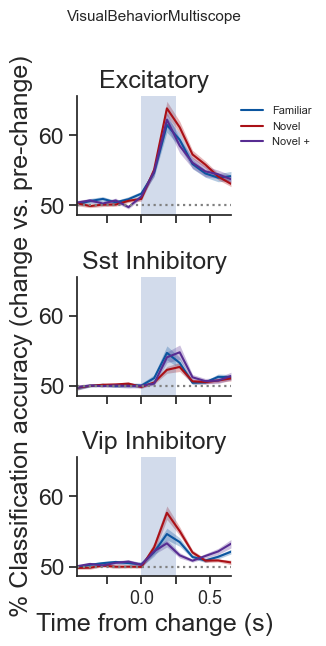

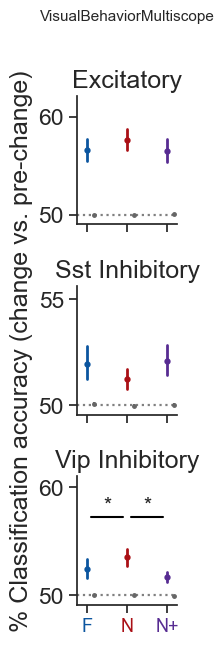

In [271]:
decoding_type = 'decode_changes_from_nochanges'
project_code  = 'VisualBehaviorMultiscope'
_ = ppf.plot_decoding_figures(
    results[decoding_type][project_code], decoding_type, experiments_table,
    project_code=project_code, input_vars=input_vars_all[decoding_type].get(project_code),
    suptitle=project_code)

### decode_changes_from_nochanges (Fig S6) -- per project code

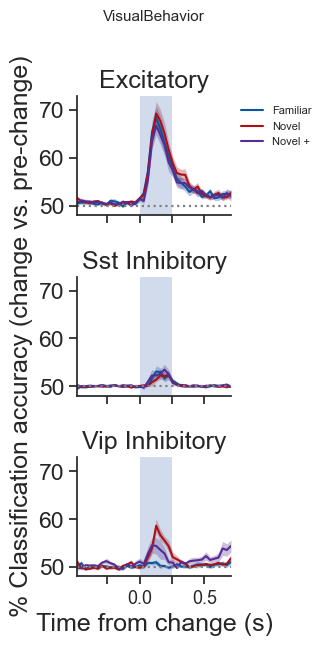

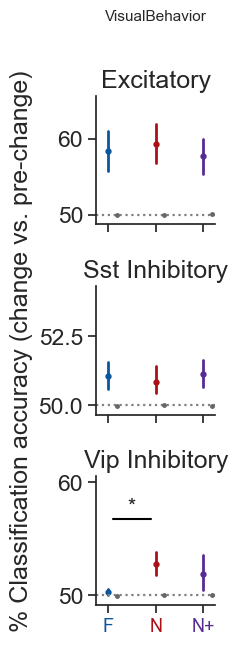

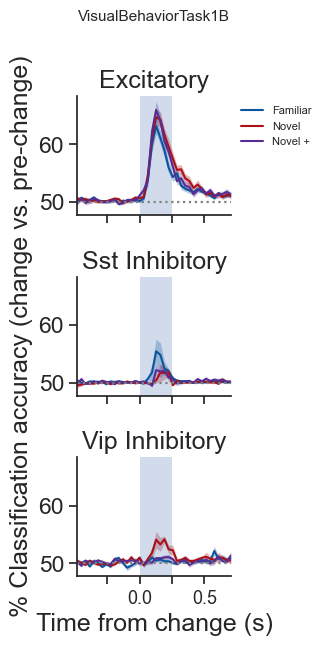

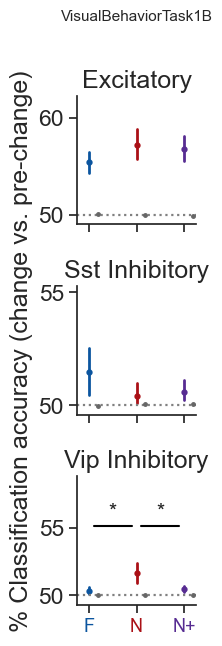

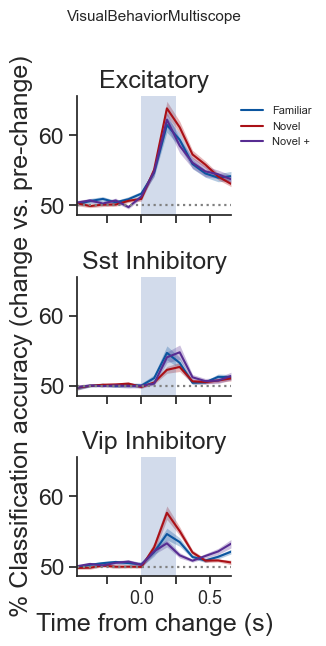

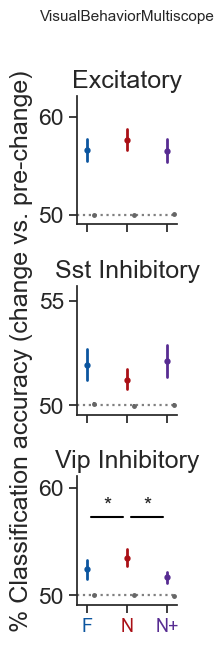

In [272]:
decoding_type = 'decode_changes_from_nochanges'
for project_code in project_codes:
    if project_code not in results[decoding_type]:
        print('[missing] %s / %s' % (decoding_type, project_code)); continue
    _ = ppf.plot_decoding_figures(
        results[decoding_type][project_code], decoding_type, experiments_table,
        project_code=project_code, input_vars=input_vars_all[decoding_type].get(project_code),
        suptitle=project_code, metrics_dir=metrics_dir, recompute_metrics=RECOMPUTE_METRICS)

### decode_next_image_from_omissions (Fig S8) -- per project code

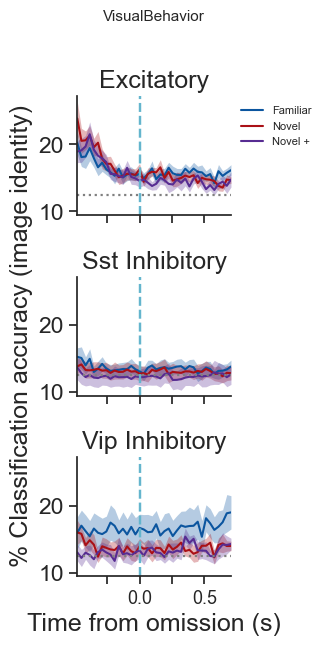

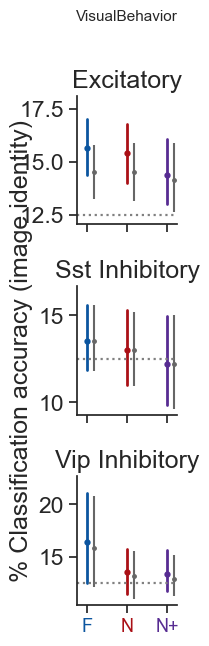

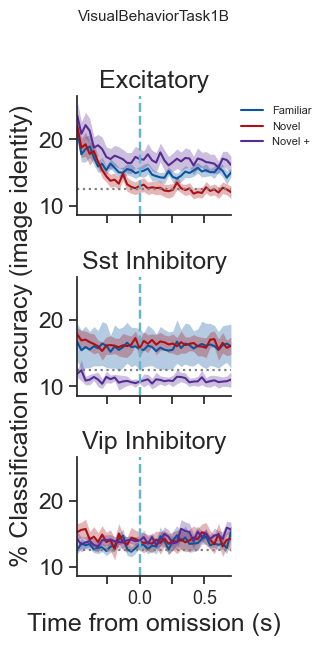

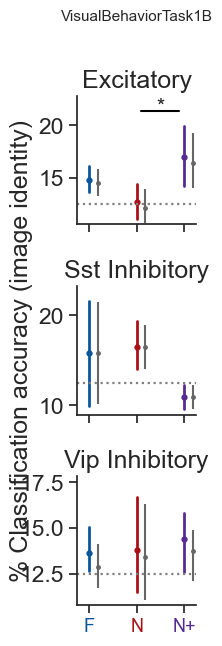

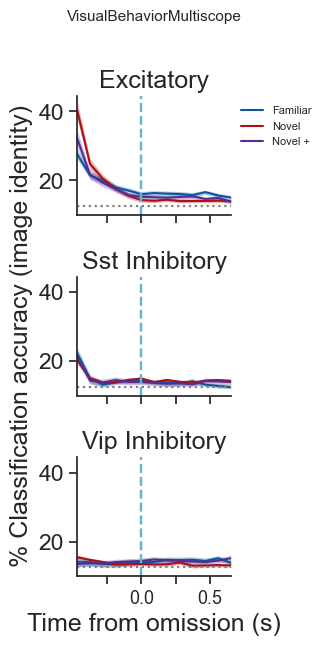

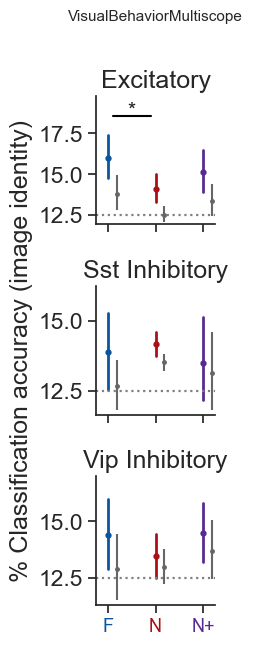

In [273]:
decoding_type = 'decode_next_image_from_omissions'
for project_code in project_codes:
    if project_code not in results[decoding_type]:
        print('[missing] %s / %s' % (decoding_type, project_code)); continue
    _ = ppf.plot_decoding_figures(
        results[decoding_type][project_code], decoding_type, experiments_table,
        project_code=project_code, input_vars=input_vars_all[decoding_type].get(project_code),
        suptitle=project_code, metrics_dir=metrics_dir, recompute_metrics=RECOMPUTE_METRICS)

### decode_baseline_from_nobaseline (Fig S7) -- per project code

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10665: RuntimeWarning: Mean of empty slice
  axes[-1].set_xlabel('Time from {} (s)'.format(DECODING_EVENT_LABEL[decoding_type]))
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10665: RuntimeWarning: Mean of empty slice
  axes[-1].set_xlabel('Time from {} (s)'.format(DECODING_EVENT_LABEL[decoding_type]))
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualiza

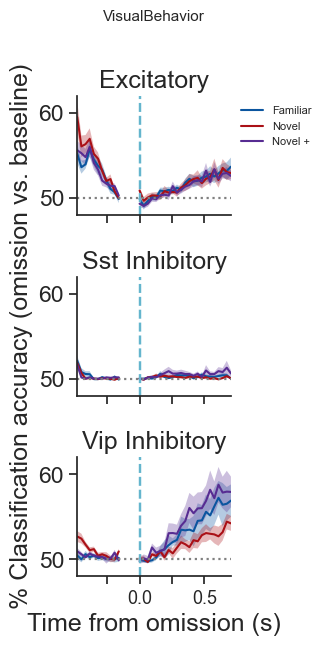

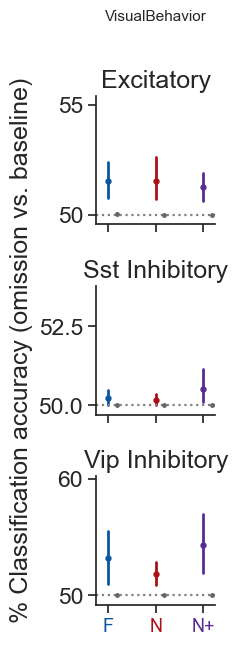

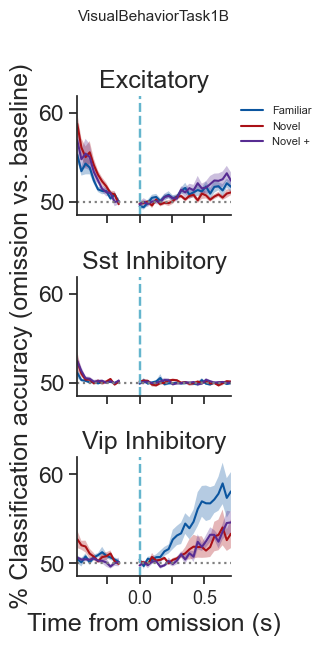

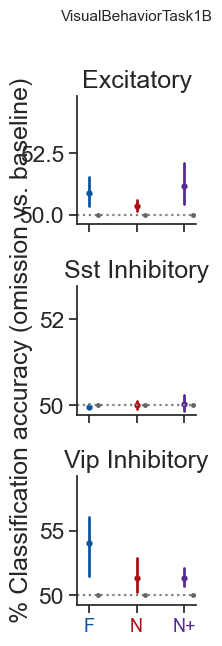

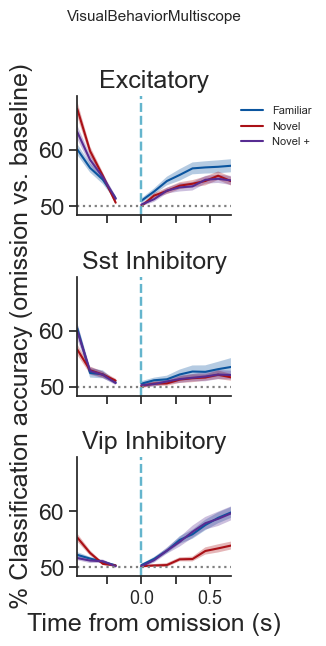

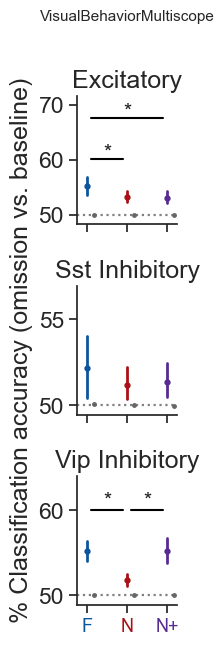

In [274]:
decoding_type = 'decode_baseline_from_nobaseline'
for project_code in project_codes:
    if project_code not in results[decoding_type]:
        print('[missing] %s / %s' % (decoding_type, project_code)); continue
    _ = ppf.plot_decoding_figures(
        results[decoding_type][project_code], decoding_type, experiments_table,
        project_code=project_code, input_vars=input_vars_all[decoding_type].get(project_code),
        suptitle=project_code, metrics_dir=metrics_dir, recompute_metrics=RECOMPUTE_METRICS)

### Aggregated across project codes (resampled to a common onset-relative grid)

`resample_decoding_across_projects` interpolates every session onto a common grid over the
overlap of the project codes' windows, pooling single- and multi-plane experiments.

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10665: RuntimeWarning: Mean of empty slice
  axes[-1].set_xlabel('Time from {} (s)'.format(DECODING_EVENT_LABEL[decoding_type]))
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10665: RuntimeWarning: Mean of empty slice
  axes[-1].set_xlabel('Time from {} (s)'.format(DECODING_EVENT_LABEL[decoding_type]))
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualiza

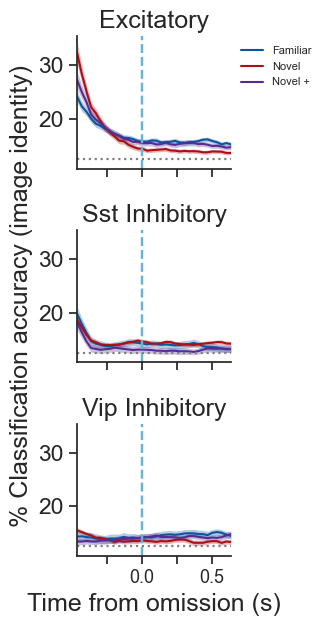

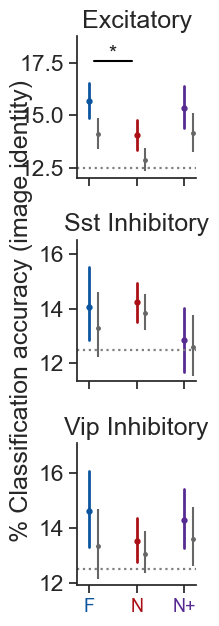

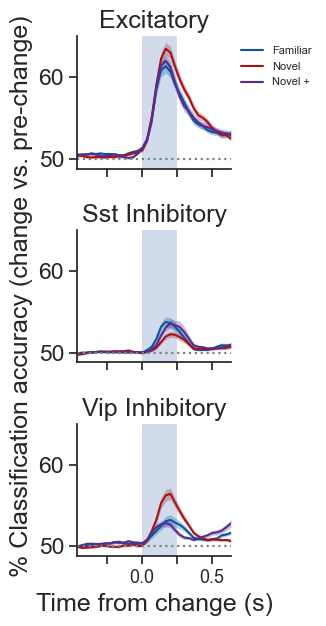

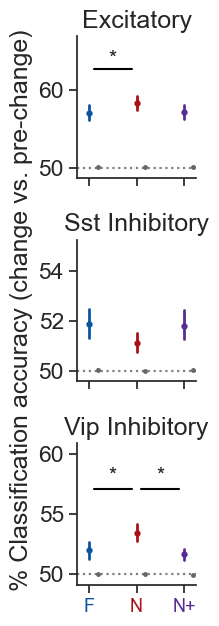

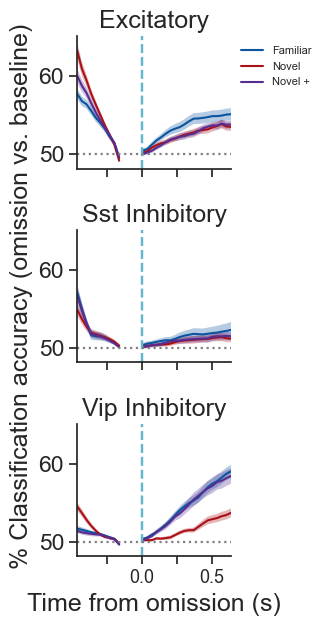

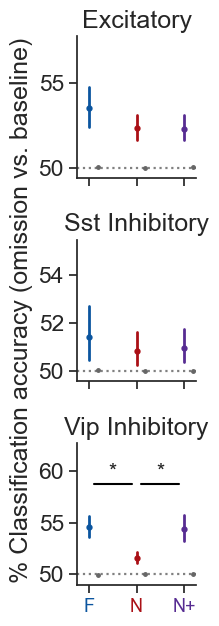

In [275]:
for decoding_type in decoding_types:
    combined, t_common = ppf.resample_decoding_across_projects(
        results, input_vars_all, decoding_type, project_codes)
    _ = ppf.plot_decoding_figures(combined, decoding_type, experiments_table, time_axis=t_common,
                                  metrics_dir=metrics_dir, recompute_metrics=RECOMPUTE_METRICS)

### Aggregated time-resolved: shared vs. independent y-axis

Plots each aggregated time-resolved figure both ways (`sharey=True` then `sharey=False`)
so the shared-scale vs. per-cell-type-scale views can be compared side by side.

decode_next_image_from_omissions  --  aggregated  --  sharey=True
decode_next_image_from_omissions  --  aggregated  --  sharey=False
decode_changes_from_nochanges  --  aggregated  --  sharey=True
decode_changes_from_nochanges  --  aggregated  --  sharey=False
decode_baseline_from_nobaseline  --  aggregated  --  sharey=True
decode_baseline_from_nobaseline  --  aggregated  --  sharey=False


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10665: RuntimeWarning: Mean of empty slice
  axes[-1].set_xlabel('Time from {} (s)'.format(DECODING_EVENT_LABEL[decoding_type]))
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10665: RuntimeWarning: Mean of empty slice
  axes[-1].set_xlabel('Time from {} (s)'.format(DECODING_EVENT_LABEL[decoding_type]))
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualiza

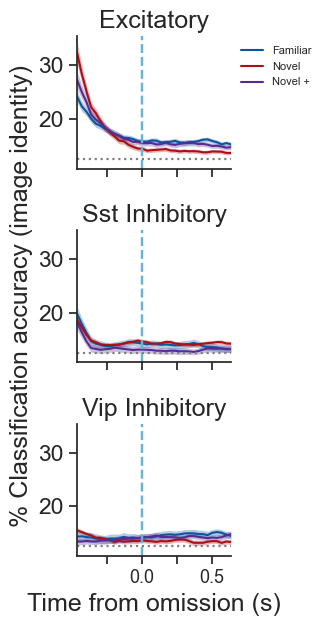

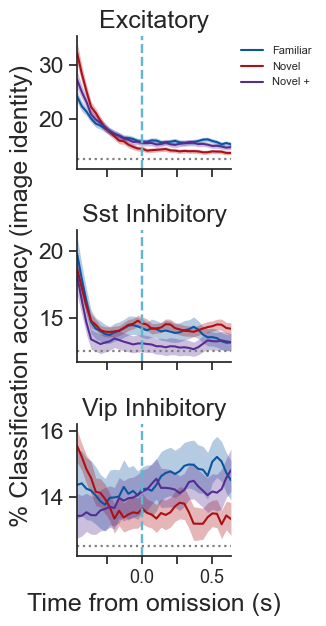

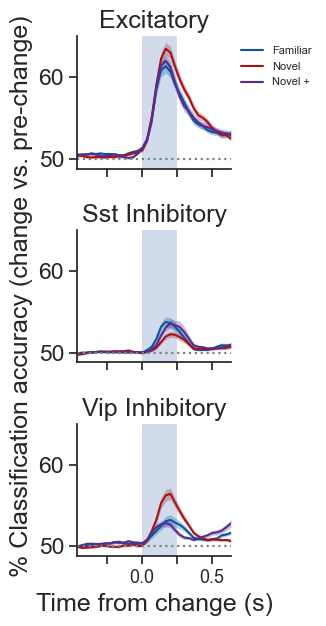

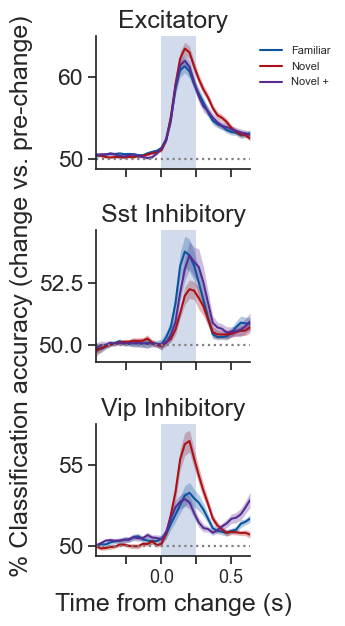

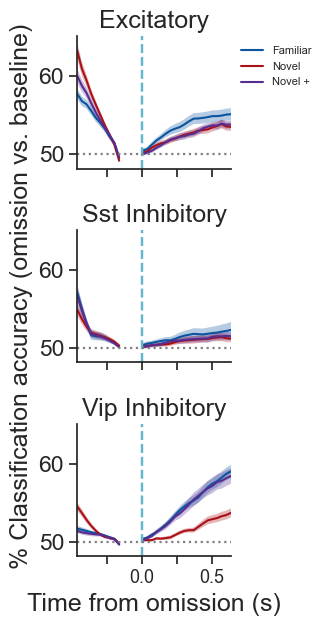

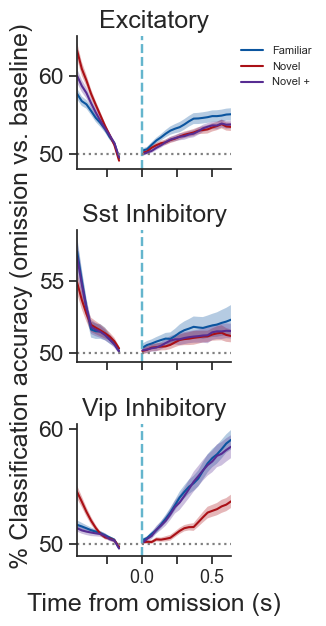

In [276]:
for decoding_type in decoding_types:
    combined, t_common = ppf.resample_decoding_across_projects(
        results, input_vars_all, decoding_type, project_codes)
    labeled = ppf.add_decoding_labels(combined, experiments_table)
    for sharey in (True, False):
        print('{}  --  aggregated  --  sharey={}'.format(decoding_type, sharey))
        axes = ppf.plot_decoding_timecourse(labeled, decoding_type, t_common, sharey=sharey)
        axes[0].get_figure().tight_layout()